# Heavy Equipment Selling Price Prediction Challenge
### MLP Project | 2026 T2

**Objective:** Explain the dataset using statistics and build classical Machine Learning regression models to predict the selling price of heavy equipment.

**Target variable:** `TargetValue`

**Evaluation metric:** RMSLE (Root Mean Squared Logarithmic Error)

---

# 1. Problem Statement

## 1.1 Business Problem

Heavy industrial equipment (excavators, wheel loaders, backhoes, etc.) is routinely bought and sold on the secondary (auction/resale) market. Unlike new equipment, the price of a used machine depends on a large number of factors — how old it is, how many hours it has been operated, its technical configuration, the region it is sold in, and the specific attachments/specifications it carries.

For a platform that facilitates these transactions (auction houses, resellers, financing companies), being able to **automatically estimate a fair selling price** for a piece of equipment is extremely valuable:

- It helps **sellers** set realistic reserve prices.
- It helps **buyers** know whether a listed price is fair.
- It helps the **platform** flag mispriced listings, detect anomalies/fraud, and build financing/insurance products around the estimated value of an asset.

Given historical transaction records (`train.csv`) containing the technical specification, usage, geography and sale details of previously sold machines along with their observed sale price, the task is to **predict the selling price (`TargetValue`) of equipment in `test.csv`** whose price is unknown.

## 1.2 Target Variable — `TargetValue`

`TargetValue` is the financial amount (in USD) at which a piece of equipment was sold. This is a **continuous, strictly positive, right-skewed** variable — most machines sell in a common price band, but a smaller number of very large/specialized machines sell for very high prices. This skew is important: it motivates working in **log space** rather than raw price space (discussed in Section 3 and 4).

## 1.3 Evaluation Metric — RMSLE

The competition uses **Root Mean Squared Logarithmic Error (RMSLE)**:

$$
\text{RMSLE} = \sqrt{ \frac{1}{n} \sum_{i=1}^{n} \Big( \log(1 + \hat{y}_i) - \log(1 + y_i) \Big)^2 }
$$

where $\hat{y}_i$ is the predicted price and $y_i$ is the actual price.

**Why RMSLE (and not plain RMSE) makes sense for this problem:**

1. **Relative error, not absolute error.** RMSLE penalizes the *ratio* between predicted and actual price rather than the raw difference. Being off by \$5,000 on a \$10,000 machine is a much bigger mistake than being off by \$5,000 on a \$200,000 machine — RMSE would treat both errors equally, RMSLE does not.
2. **Robust to the right-skew of price.** Since a few machines are extremely expensive, RMSE would be dominated by errors on those few high-value machines. RMSLE compresses the scale via the log, making the metric fairer across the whole price range.
3. **Symmetric-ish penalty for under/over-estimation** in relative terms — it slightly favours models that avoid *under-predicting* by large multiplicative margins.

**Practical consequence for modelling:** since the metric is computed in log-space, it is natural to **train our models on `log1p(TargetValue)`** and evaluate by exponentiating (`expm1`) the predictions back to the original scale before comparing to the ground truth. We do this throughout the notebook.

# 2. Dataset Understanding

We load the three files provided:

- `train.csv` — historical transactions with the known `TargetValue`
- `test.csv` — transactions for which we must predict `TargetValue`
- `sample_submission.csv` — the expected submission format
- `metadata.csv` — a data dictionary describing every column


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy.stats import randint, uniform

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:

TRAIN_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv"                
TEST_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv"
SAMPLE_SUBMISSION_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv"
METADATA_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv"

train_data = pd.read_csv(TRAIN_PATH, low_memory=False)
test_data = pd.read_csv(TEST_PATH, low_memory=False)
sample_submission = pd.read_csv(SAMPLE_SUBMISSION_PATH)
metadata = pd.read_csv(METADATA_PATH)

TARGET = "TargetValue"
ID_COL = "TransactionID"

train_data.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [3]:
test_data.head()

,TransactionID,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,Spec_FullDescriptor,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139307,999097,3168,ACH138,GTX,2005,68.0,Low,2007-11-16,521D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139419,1018084,1344,ACH138,GTX,1999,10466.0,Medium,2007-06-01,345BL,...,Steel,None or Unspecified,"15' 9""",None or Unspecified,Yes,Double,NaN,NaN,NaN,NaN
2,1139482,1048712,2808,ACH138,GTX,2001,3817.0,Low,2012-06-16,EX120-5,...,Steel,None or Unspecified,None or Unspecified,Hydraulic,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139522,697537,1089,ACH138,GTX,2006,1498.0,Medium,2010-08-27,304CR,...,Rubber,16 inch,None or Unspecified,Manual,Yes,Double,NaN,NaN,NaN,NaN
4,1139684,1048082,16781,ACH138,GTX,2009,22.0,Low,2010-07-09,L2800D,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print(train_data.columns.tolist())

['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID', 'DataOriginCode', 'VendorPartnerID', 'ManufactureYear', 'OperationalHoursMeter', 'UtilizationTier', 'TransactionDate', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18', 'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30']


### Shape and Data Types

In [5]:
print(f"Train shape: {train_data.shape}")
print(f"Test shape : {test_data.shape}")

Train shape: (138701, 50)
Test shape : (15000, 49)


In [6]:
def dtype_summary(df, name):
    summary = pd.DataFrame({
        "dtype": df.dtypes,
        "n_unique": df.nunique(),
        "n_missing": df.isnull().sum(),
        "pct_missing": (df.isnull().mean() * 100).round(2)
    }).sort_values("pct_missing", ascending=False)
    display(Markdown(f"**{name} — column summary**"))
    display(summary)
    return summary

train_summary = dtype_summary(train_data, "Train data")

**Train data — column summary**

,dtype,n_unique,n_missing,pct_missing
col19,object,2,138635,99.95
col18,object,2,138635,99.95
col5,object,2,128320,92.52
col4,object,2,128320,92.52
col27,object,9,123742,89.21
col28,object,5,123742,89.21
col29,object,3,119829,86.39
col30,object,2,119829,86.39
col13,object,2,115296,83.13
col14,object,3,115296,83.13


**Observation:** The dataset is a mix of true numeric fields (`ManufactureYear`, `OperationalHoursMeter`), identifier columns with very high cardinality (`AssetID`, `ProductConfigID`, `Spec_FullDescriptor`), low/medium-cardinality categorical fields (`RegionCode`, `UtilizationTier`, `DrivetrainType`, ...), and a large block of technical specification columns (`col1`–`col30`) that describe optional attachments/configuration and are therefore only populated for the equipment types where they apply — this is *why* so many of the `colN` columns show very high missingness (missing here often means "not applicable" rather than "unknown").

In [7]:

train_data.describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,138701.0,2.186276e+06,1.128497e+06,1139309.0,1465754.0,1751884.0,2372139.0,6333410.0
TargetValue,138701.0,4.152187e+04,2.636113e+04,7500.0,20500.0,35000.0,57000.0,142000.0
AssetID,138701.0,1.204814e+06,5.287376e+05,8.0,1007930.0,1246956.0,1495817.0,2478476.0
ProductConfigID,138701.0,7.286422e+03,7.542422e+03,39.0,1693.0,3852.0,11873.0,37209.0
ManufactureYear,138701.0,1.891641e+03,3.069920e+02,1001.0,1990.0,1998.0,2004.0,2015.0
OperationalHoursMeter,82058.0,4.553719e+03,2.792204e+04,0.0,0.0,1620.0,5001.0,1729600.0


In [8]:
train_data.describe(include="object").T

,count,unique,top,freq
DataOriginCode,138701,6,ADI149,59541
VendorPartnerID,138701,31,UJF,67828
UtilizationTier,50475,3,Medium,24588
TransactionDate,138701,3676,2010-02-16,1159
Spec_FullDescriptor,138701,3505,140G,3751
Spec_BaseClass,138701,1249,12,5702
Spec_SubClass,101716,147,G,17381
Spec_ReleaseSeries,32896,113,II,8425
Spec_VariantModifier,52332,132,L,14496
AssetScaleFactor,97491,6,Large / Medium,39222


### Feature Descriptions (Data Dictionary)

`metadata.csv` gives a business-friendly description for every column — we use it throughout the notebook to reason about *why* a feature might matter, rather than treating every column as an anonymous number/string.

In [9]:
pd.set_option("display.max_colwidth", 120)
metadata

,Variable,Rephrased Description
0,TransactionID,A unique serial number assigned to each individual accounting record.
1,TargetValue,"The financial amount of the transaction, denominated in US Dollars."
2,AssetID,The internal tracking number assigned to a specific piece of hardware.
3,ProductConfigID,A system-generated code representing the technical build-out of the unit.
4,DataOriginCode,A code indicating the specific software or platform where the data originated.
5,VendorPartnerID,The unique ID of the external entity or third-party provider involved.
6,TransactionDate,The official calendar date when the entry was finalized in the system.
7,RegionCode,The specific geographic area or legal jurisdiction where the event occurred.
8,ManufactureYear,The year the asset was originally produced.
9,OperationalHoursMeter,The lifetime total of active run-time or work cycles logged by the machine.


# 3. Exploratory Data Analysis

Our EDA is structured to directly inform the preprocessing and feature engineering steps that follow:

1. Missing values — which columns need imputation vs. which convey information through their *absence*.
2. Duplicates.
3. Cardinality — which columns are usable categoricals vs. IDs that need special encoding.
4. Target variable behaviour.
5. Univariate analysis (numeric + categorical).
6. Bivariate analysis against the target.
7. Correlation analysis.
8. A simple time/age analysis, since equipment age is usually one of the strongest price drivers.

## 3.1 Missing Value Analysis

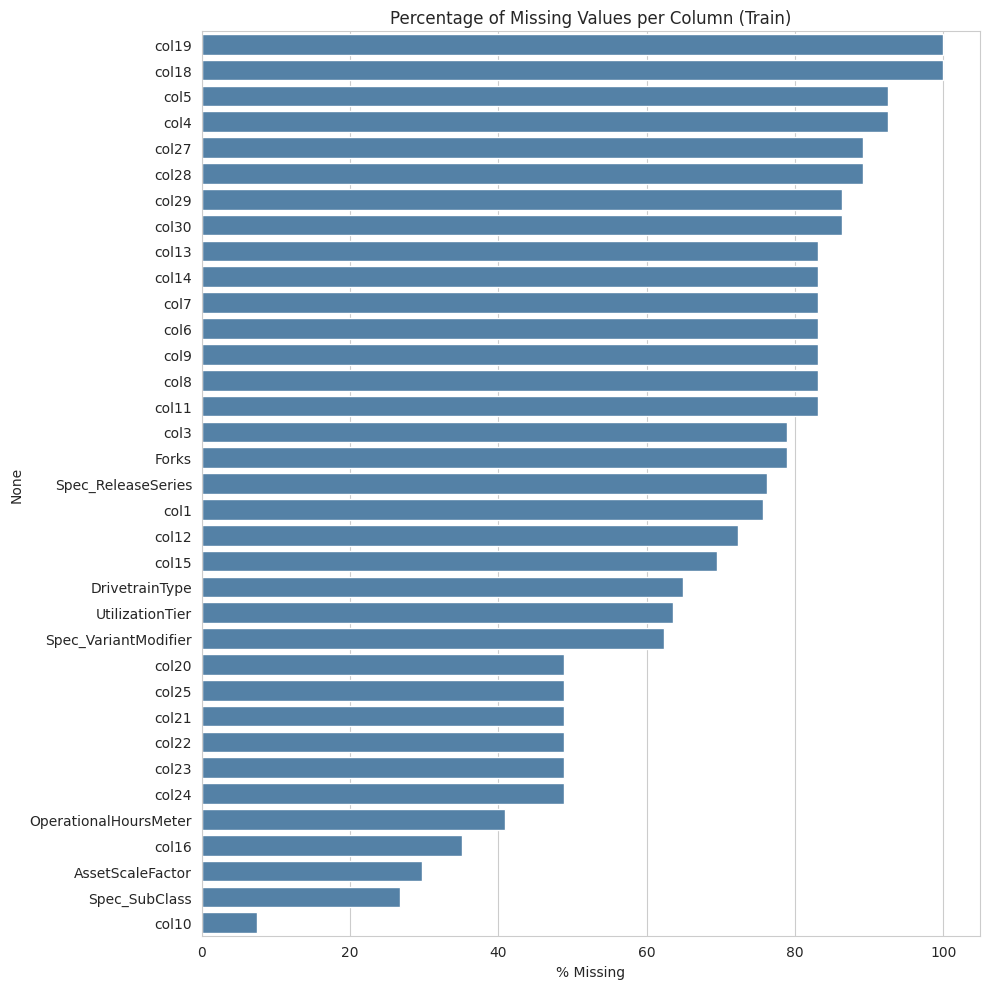

col19                    99.952416
col18                    99.952416
col5                     92.515555
col4                     92.515555
col27                    89.214930
col28                    89.214930
col29                    86.393753
col30                    86.393753
col13                    83.125572
col14                    83.125572
col7                     83.125572
col6                     83.125572
col9                     83.125572
col8                     83.125572
col11                    83.125572
col3                     78.909309
Forks                    78.861724
Spec_ReleaseSeries       76.282795
col1                     75.641127
col12                    72.340502
col15                    69.519326
DrivetrainType           64.856057
UtilizationTier          63.608770
Spec_VariantModifier     62.269919
col20                    48.799216
col25                    48.799216
col21                    48.799216
col22                    48.797774
col23               

In [10]:
missing_pct = (train_data.isnull().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

plt.figure(figsize=(10, 10))
sns.barplot(x=missing_pct.values, y=missing_pct.index, color="steelblue")
plt.xlabel("% Missing")
plt.title("Percentage of Missing Values per Column (Train)")
plt.tight_layout()
plt.show()

missing_pct

**Interpretation.** Columns above ~70–80% missing are almost all `colN` technical/attachment specification fields — for these, missingness is very likely **structural** (the attachment/spec simply doesn't apply to that equipment type) rather than a data-quality problem. We handle this in two complementary ways later:

- Impute with an explicit `"Missing"` / `"None"` category (not the mode) so the model can *use* the fact that a value is absent.
- For the columns with extremely high missingness, additionally create a binary `HasX` indicator flag, since the presence/absence of a spec can itself be predictive of price (e.g. a machine that *has* a reported "Blade Width" is likely a different, possibly more expensive, class of machine than one that doesn't).

Numeric columns such as `OperationalHoursMeter` have moderate missingness and are imputed with the **median** (robust to skew/outliers) inside a pipeline fit only on the training fold, to avoid leakage.

## 3.2 Duplicate Records

In [11]:
print("Fully duplicated rows:", train_data.duplicated().sum())
print("Duplicated TransactionIDs:", train_data[ID_COL].duplicated().sum())

Fully duplicated rows: 0
Duplicated TransactionIDs: 0


`TransactionID` is expected to be unique (it is the primary key of a transaction record). If duplicate rows exist they are dropped, since a duplicated transaction adds no new information and would let the same observation influence training twice.

In [12]:
train_data = train_data.drop_duplicates().reset_index(drop=True)
print("Shape after dropping full-row duplicates:", train_data.shape)

Shape after dropping full-row duplicates: (138701, 50)


## 3.3 Cardinality Analysis

In [13]:
cardinality = train_data.nunique().sort_values(ascending=False)
cardinality.head(15)

TransactionID               138701
AssetID                     120111
OperationalHoursMeter        14643
TransactionDate               3676
ProductConfigID               3594
Spec_FullDescriptor           3505
Spec_BaseClass                1249
TargetValue                    675
Spec_SubClass                  147
Spec_VariantModifier           132
Spec_ReleaseSeries             113
ManufactureYear                 68
FunctionalClassification        65
RegionCode                      53
VendorPartnerID                 31
dtype: int64

In [14]:
categorical_dtype_cols = train_data.select_dtypes(include="object").columns.tolist()
high_cardinality_cols = [c for c in categorical_dtype_cols
                          if c not in [ID_COL, TARGET, "TransactionDate"] and train_data[c].nunique() > 200]

NUMERIC_ID_COLS = ["AssetID", "ProductConfigID"]
high_cardinality_cols = high_cardinality_cols + [c for c in NUMERIC_ID_COLS if c in train_data.columns]
print("High-cardinality columns:", high_cardinality_cols)

constant_cols = [c for c in train_data.columns if train_data[c].nunique(dropna=False) <= 1]
print("Constant / zero-variance columns:", constant_cols)

High-cardinality columns: ['Spec_FullDescriptor', 'Spec_BaseClass', 'AssetID', 'ProductConfigID']
Constant / zero-variance columns: []


**Why this matters:** `AssetID`, `ProductConfigID` and `Spec_FullDescriptor` have hundreds to thousands of unique values. One-hot encoding them would explode the feature space and mostly memorize noise. Instead, in the Feature Engineering section we convert them to **frequency encodings** (how common that ID/spec is in the training data), which keeps the useful signal in a single numeric column. Constant columns (if any) are dropped since they cannot help distinguish price.

## 3.4 Target Variable Analysis

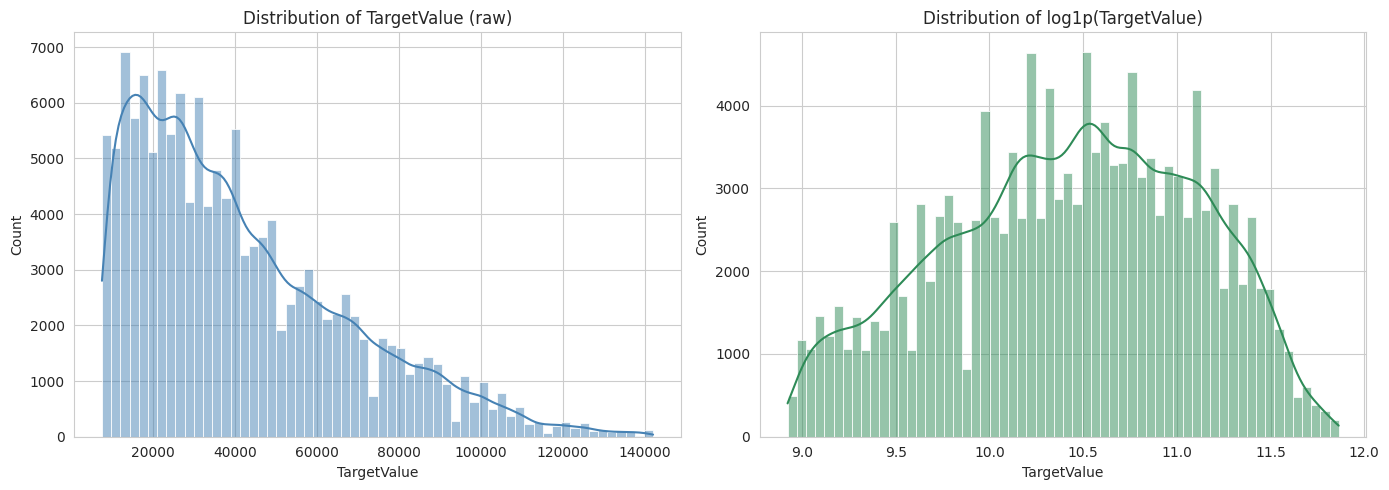

Skewness (raw)   : 0.97
Skewness (log1p) : -0.198


count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_data[TARGET], bins=60, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of TargetValue (raw)")

sns.histplot(np.log1p(train_data[TARGET]), bins=60, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Distribution of log1p(TargetValue)")

plt.tight_layout()
plt.show()

print("Skewness (raw)   :", train_data[TARGET].skew().round(3))
print("Skewness (log1p) :", np.log1p(train_data[TARGET]).skew().round(3))
train_data[TARGET].describe()

**Interpretation.** The raw `TargetValue` is right-skewed (a long tail of expensive machines pulling the mean above the median), which matches the intuition from Section 1.3 about why RMSLE is the right metric. After a `log1p` transform the distribution becomes much closer to symmetric/normal. This directly motivates training our regression models on `log1p(TargetValue)`:

- It makes the target's distribution better suited to linear models' assumptions.
- Optimizing squared error on the log-transformed target is mathematically equivalent to optimizing RMSLE on the original scale.

## 3.5 Univariate Analysis — Numerical Features

Numeric feature columns: ['ManufactureYear', 'OperationalHoursMeter']


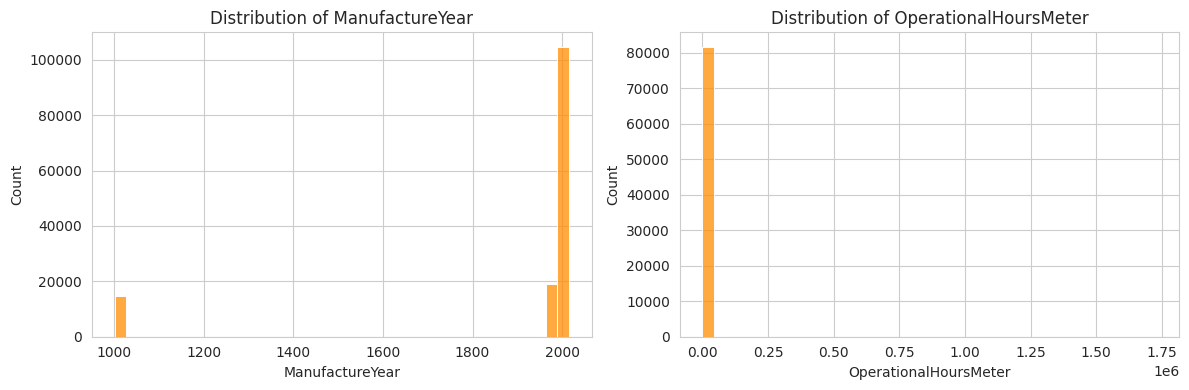

In [16]:
numeric_cols = train_data.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in [ID_COL, TARGET, "AssetID", "ProductConfigID"]]
print("Numeric feature columns:", numeric_cols)

n = len(numeric_cols)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
if n == 1:
    axes = [axes]
for ax, col in zip(axes, numeric_cols):
    sns.histplot(train_data[col].dropna(), bins=40, ax=ax, color="darkorange")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

**Interpretation guidance:** `ManufactureYear` typically shows most machines manufactured in a fairly recent, concentrated window, with a long tail of much older vintage equipment. `OperationalHoursMeter` (a usage/wear measure) is usually strongly right-skewed — most machines are lightly used, a few have very high accumulated hours. This skew is another candidate for a log transform during Feature Engineering.

## 3.6 Univariate Analysis — Categorical Features

Categorical columns plotted: ['DataOriginCode', 'UtilizationTier', 'AssetScaleFactor', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col16', 'col18', 'col19', 'col20', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30']


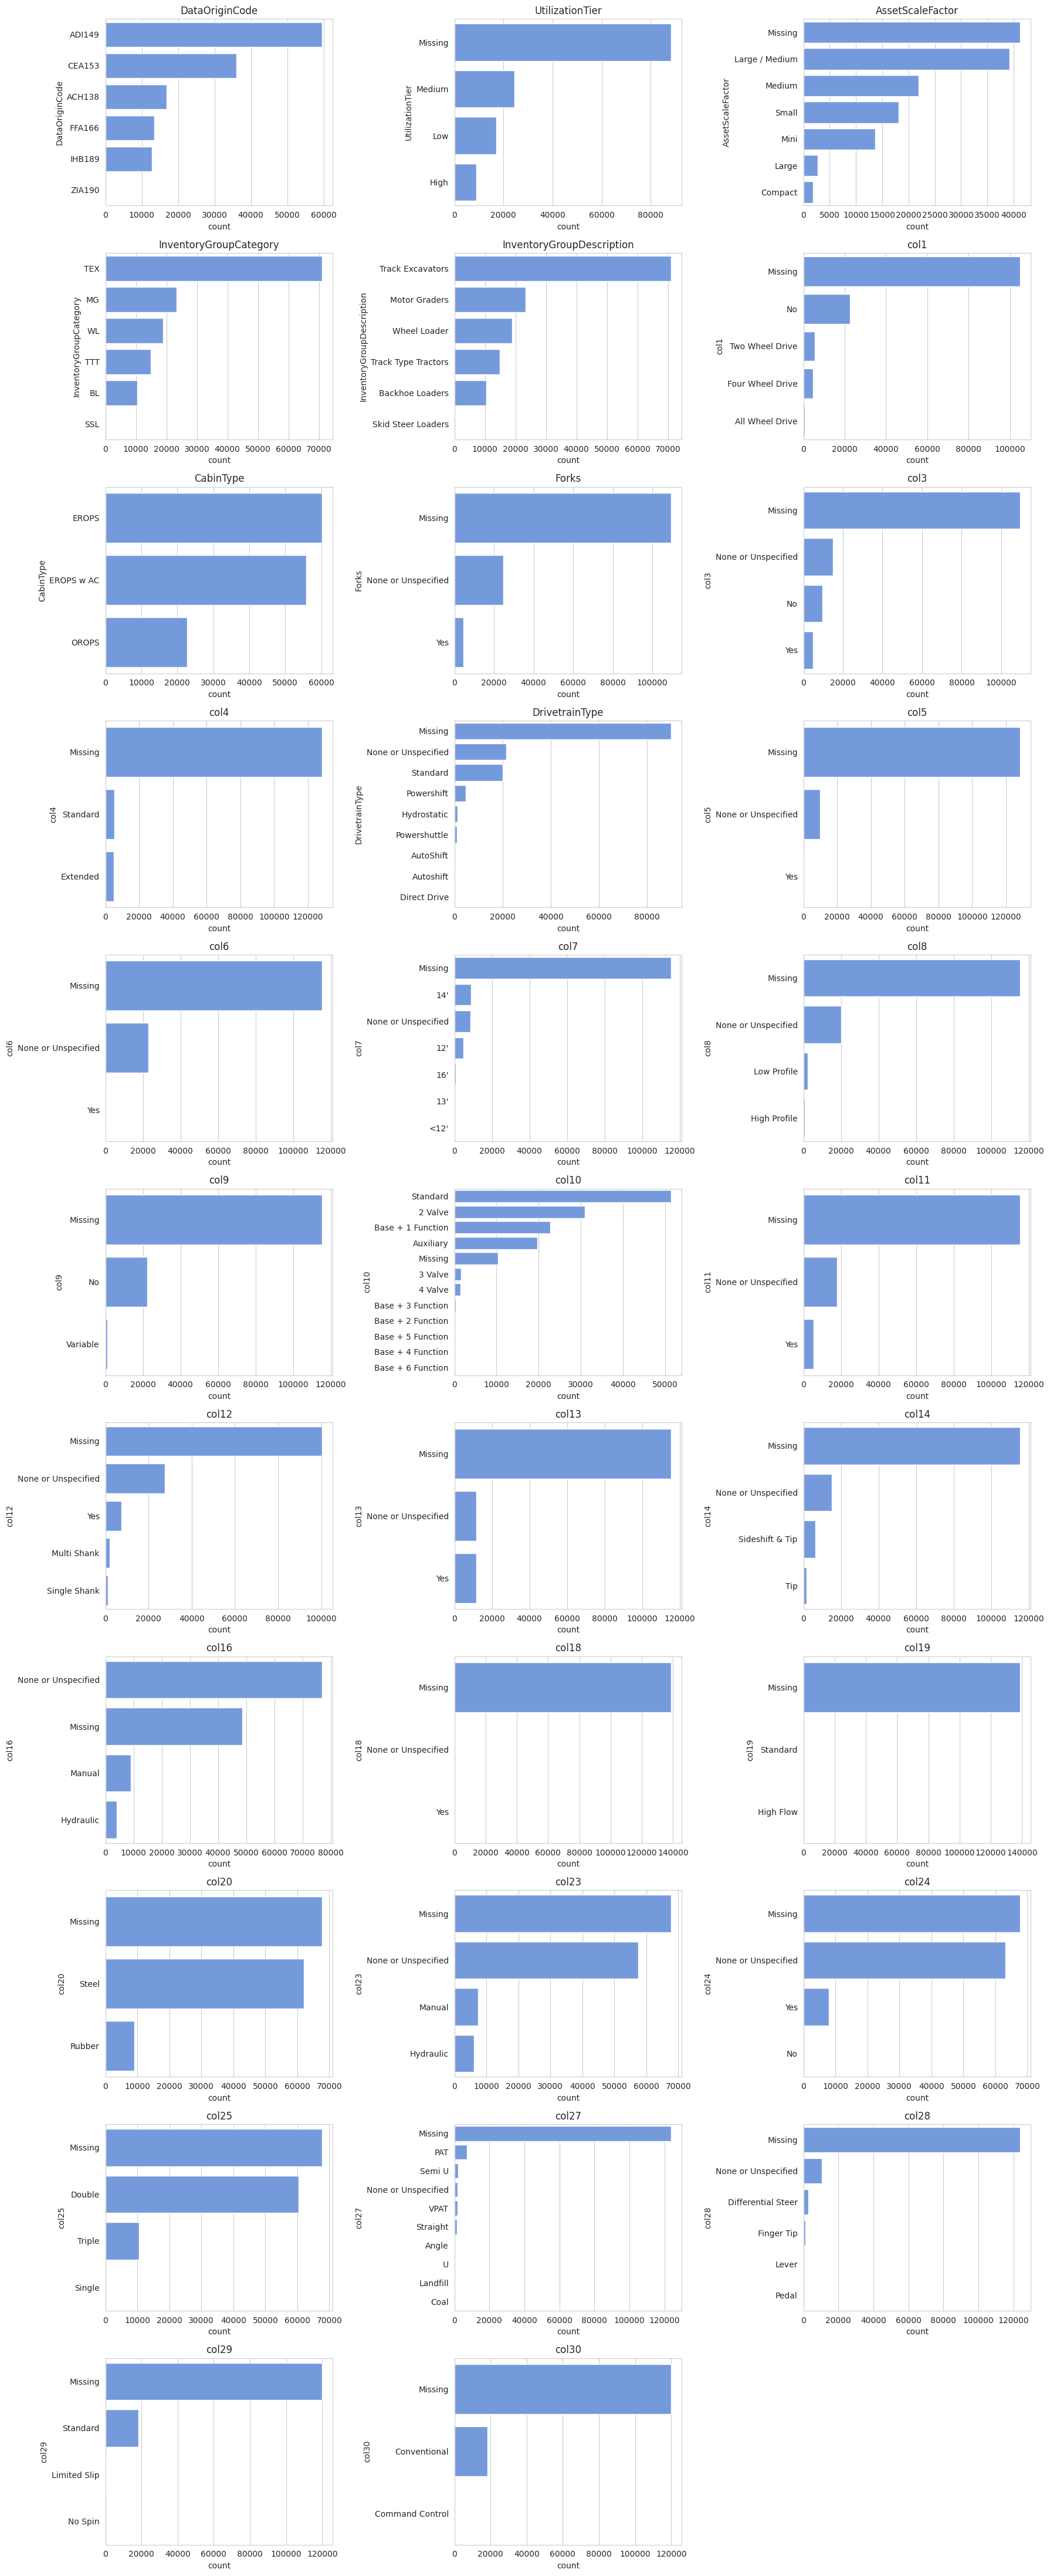

In [17]:
categorical_cols = train_data.select_dtypes(include=["object"]).columns.tolist()
categorical_cols = [c for c in categorical_cols if c not in high_cardinality_cols + ["TransactionDate"]]

# For readability, only plot categorical features with a manageable number of levels
plot_cat_cols = [c for c in categorical_cols if train_data[c].nunique(dropna=False) <= 12]
print("Categorical columns plotted:", plot_cat_cols)

n_cols = 3
n_rows = int(np.ceil(len(plot_cat_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, plot_cat_cols):
    
    col_series = train_data[col].fillna("Missing").astype(str)
    order = col_series.value_counts().index
    sns.countplot(y=col_series, order=order, ax=ax, color="cornflowerblue")
    ax.set_title(col)

for ax in axes[len(plot_cat_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

**Interpretation guidance:** Fields like `UtilizationTier` and `DrivetrainType` typically have one dominant category and a long "Missing" bar reflecting the structural missingness discussed earlier. `RegionCode` (US states) will have many levels — it is kept but not shown here in full; it is handled with one-hot encoding since its cardinality, while larger, is still manageable (tens, not thousands, of categories).

## 3.7 Bivariate Analysis — Features vs. Target

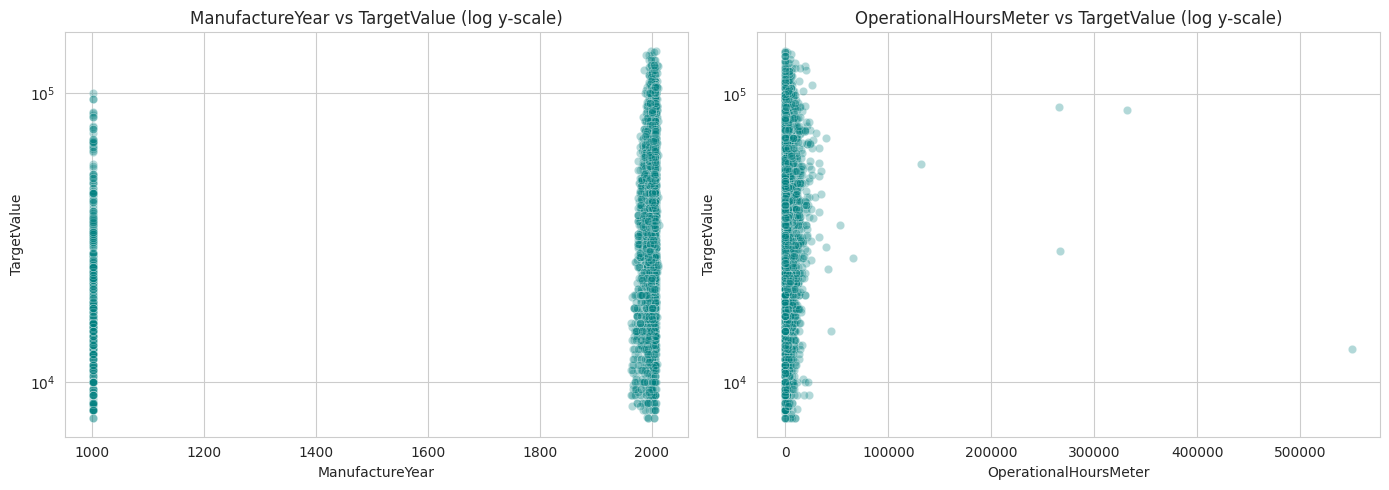

In [18]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(7 * len(numeric_cols), 5))
if len(numeric_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, numeric_cols):
    sample = train_data[[col, TARGET]].dropna().sample(min(3000, train_data.shape[0]), random_state=RANDOM_STATE)
    sns.scatterplot(data=sample, x=col, y=TARGET, alpha=0.3, ax=ax, color="teal")
    ax.set_yscale("log")
    ax.set_title(f"{col} vs {TARGET} (log y-scale)")
plt.tight_layout()
plt.show()

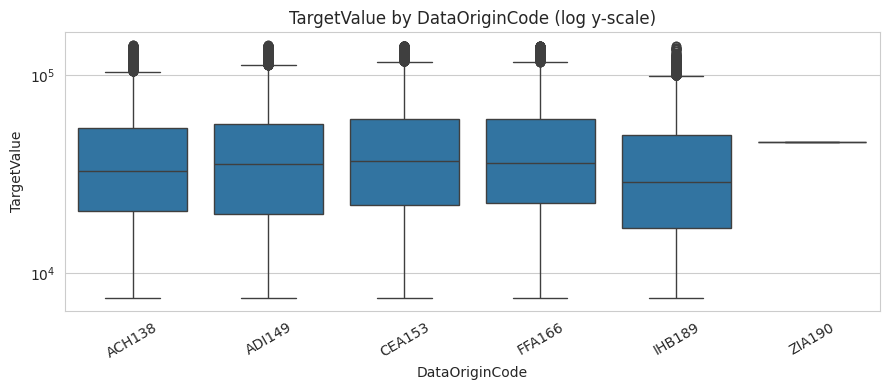

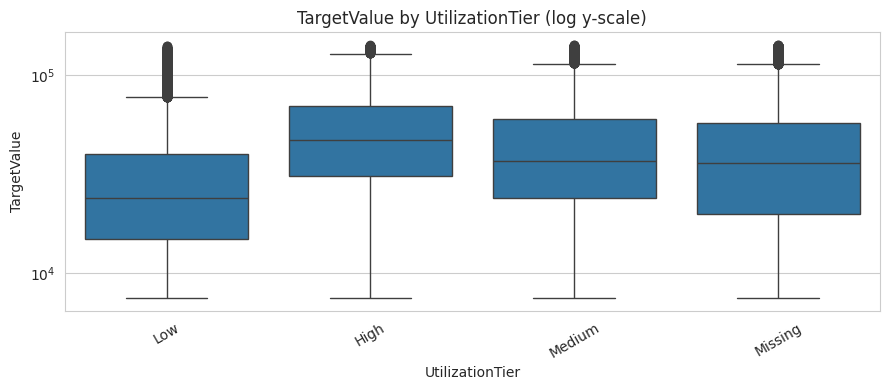

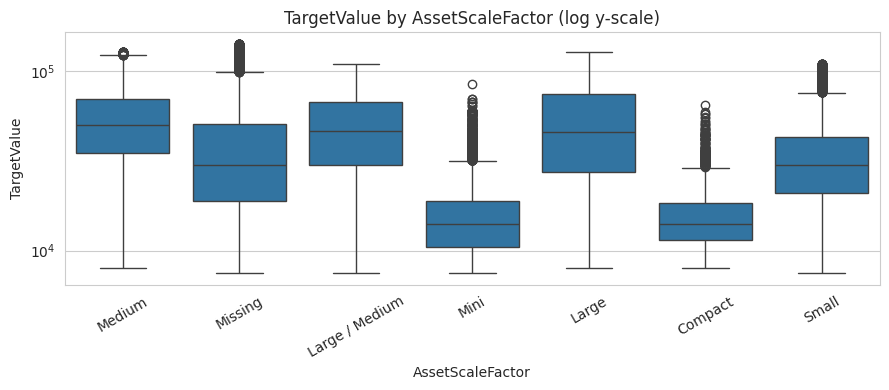

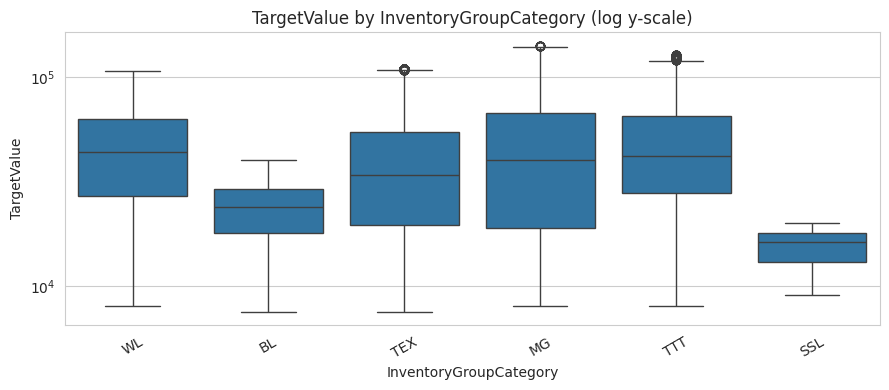

In [19]:
for col in plot_cat_cols[:4]:
    col_str = train_data[col].fillna("Missing").astype(str)
    top_levels = col_str.value_counts().head(8).index
    subset = train_data.loc[col_str.isin(top_levels)].copy()
    subset[col] = col_str.loc[subset.index]
    plt.figure(figsize=(9, 4))
    sns.boxplot(data=subset, x=col, y=TARGET)
    plt.yscale("log")
    plt.title(f"{TARGET} by {col} (log y-scale)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

**Interpretation guidance:** Newer `ManufactureYear` and lower `OperationalHoursMeter` (less wear) are generally associated with a higher selling price — consistent with straightforward depreciation/usage economics. Categorical fields such as `UtilizationTier` and equipment class fields tend to show clearly different median price bands per level, confirming they carry real predictive signal and are worth encoding carefully rather than dropping.

## 3.8 Correlation Analysis

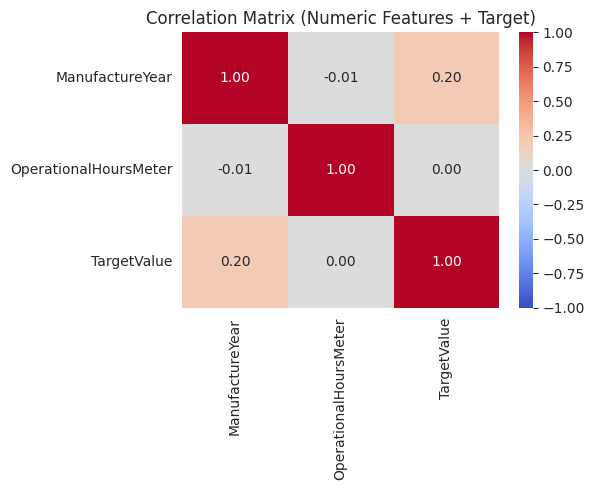

In [20]:
corr_df = train_data[numeric_cols + [TARGET]].copy()
corr_matrix = corr_df.corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix (Numeric Features + Target)")
plt.tight_layout()
plt.show()

**Interpretation.** Raw linear correlation between individual numeric columns and price is often modest — this is expected, since price is really driven by an *interaction* of equipment type, age, usage and specification, not by any single numeric column in isolation. This is exactly why the Feature Engineering section focuses on constructing an **age** feature and on encoding the categorical/spec information properly, rather than relying on the two raw numeric columns alone.

## 3.9 Equipment Age — a Quick Time-Based Look

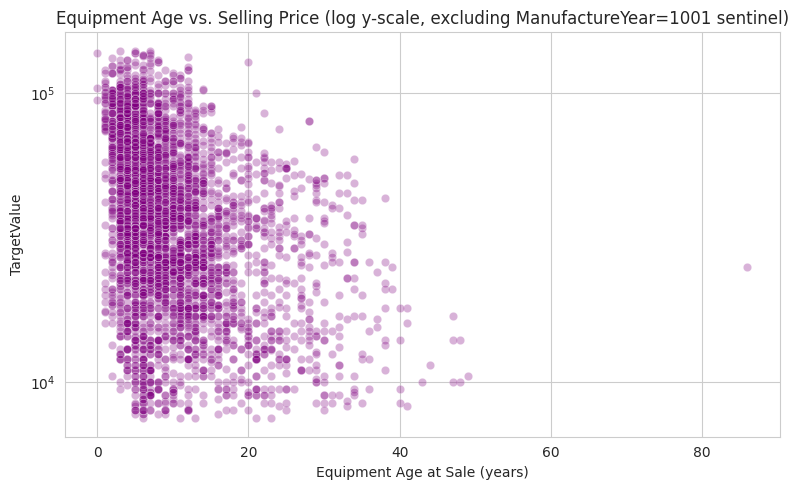

Rows with ManufactureYear sentinel (1001, 'unknown'): 14719 (10.6%)


In [21]:
train_data["TransactionDate_parsed"] = pd.to_datetime(train_data["TransactionDate"], errors="coerce")
train_data["TransactionYear_tmp"] = train_data["TransactionDate_parsed"].dt.year
age_tmp = (train_data["TransactionYear_tmp"] - train_data["ManufactureYear"]).clip(lower=0)

plot_mask = train_data["ManufactureYear"] != 1001

plt.figure(figsize=(8, 5))
sample_idx = age_tmp[plot_mask].dropna().sample(min(4000, age_tmp[plot_mask].dropna().shape[0]), random_state=RANDOM_STATE).index
sns.scatterplot(x=age_tmp.loc[sample_idx], y=train_data.loc[sample_idx, TARGET], alpha=0.3, color="purple")
plt.yscale("log")
plt.xlabel("Equipment Age at Sale (years)")
plt.ylabel(TARGET)
plt.title("Equipment Age vs. Selling Price (log y-scale, excluding ManufactureYear=1001 sentinel)")
plt.tight_layout()
plt.show()

print(f"Rows with ManufactureYear sentinel (1001, 'unknown'): {(~plot_mask).sum()} ({(~plot_mask).mean()*100:.1f}%)")

train_data.drop(columns=["TransactionDate_parsed", "TransactionYear_tmp"], inplace=True)

**Interpretation.** There is a clear downward trend — older equipment at time of sale tends to sell for less, a classic depreciation curve. This confirms that **`EquipmentAge = TransactionYear - ManufactureYear`** (built formally in Section 5) should be one of the most informative engineered features in the model.

**Data-quality note.** `ManufactureYear` also contains a sentinel value of `1001` for ~10.6% of rows (train and test alike) — clearly a "year unknown" placeholder rather than a real manufacture year, since no equipment predates the 20th century here. This is handled explicitly in Section 5 with a `ManufactureYear_Missing` indicator flag.

# 4. Data Preprocessing

**Best-practice rule we follow throughout:** all preprocessing (imputation, encoding) is defined as `sklearn` `Pipeline` / `ColumnTransformer` objects and is **fit only on the training split**, then used to `transform` the validation and test data. This prevents information from the validation/test sets leaking into how we impute the training data.

Steps:
1. Split off a validation set *before* fitting any preprocessing.
2. Separate feature types: numeric, low-cardinality categorical, high-cardinality (frequency-encoded), and "has-value" indicator columns.
3. Build a single reusable `ColumnTransformer`:
   - Numeric → `SimpleImputer(strategy="median")` (median is robust to the skew/outliers seen in Section 3.5)
   - Categorical → `SimpleImputer(strategy="constant", fill_value="Missing")` → `OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)`
4. Wrap the transformer + model together in one `Pipeline` per model, so every model always preprocesses data identically and correctly (fit on train, transform on val/test).



In [22]:
y_full = np.log1p(train_data[TARGET])
X_full = train_data.drop(columns=[TARGET])

X_train_raw, X_val_raw, y_train_log, y_val_log = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_STATE
)

print("Train:", X_train_raw.shape, " Val:", X_val_raw.shape)

Train: (110960, 49)  Val: (27741, 49)


# 5. Feature Engineering

We engineer features that turn raw, hard-to-use columns into signals a classical ML model can exploit directly:

| New feature | Built from | Why it helps |
|---|---|---|
| `ManufactureYear_Missing` | `ManufactureYear` | `ManufactureYear` uses a sentinel value of `1001` for ~10.6% of rows to mean "unknown" (Section 3.9). An explicit flag surfaces this as clean information instead of a nonsensical raw year. |
| `EquipmentAge` | `TransactionDate`, `ManufactureYear` | Directly captures depreciation — Section 3.9 showed a clear age–price relationship that the raw year columns alone don't expose as cleanly. |
| `TransactionYear`, `TransactionMonth` | `TransactionDate` | Captures market-level price trends and seasonality in the resale market. |
| `OperationalHoursMeter_log` | `OperationalHoursMeter` | The raw usage-hours column is heavily right-skewed (Section 3.5); log-transforming stabilises variance for the linear model. |
| `AssetID_freq`, `ProductConfigID_freq`, `SpecFullDescriptor_freq` | High-cardinality ID/spec columns | One-hot encoding thousands of categories is infeasible and mostly noise (Section 3.3). Frequency encoding keeps a compact numeric signal ("how common is this configuration?") without exploding dimensionality or leaking target information. `AssetID`/`ProductConfigID` are numeric dtype, so they need to be explicitly flagged as high-cardinality identifiers (Section 3.3 fix) or they would otherwise leak through as raw, near-unique numeric IDs. |
| `Has_<colN>` indicator flags | The `colN` columns with >70% missingness | Section 3.1 showed missingness in these columns is largely structural (the attachment doesn't apply); whether a spec is *reported at all* can itself correlate with equipment type/price. |

All of this is implemented as a single reusable function `engineer_features(df, freq_maps=None)` so that it is applied **identically** to train, validation and test — and so frequency maps are learned only on the training data (avoiding leakage) and simply looked up (not re-learned) on validation/test.

**Leakage fix applied throughout this section:** the *set of columns* flagged as "high-cardinality" or "high-missingness" is now recomputed from `X_train_raw` (the post-split training data) instead of the full `train_data` used for EDA — deciding which columns get special treatment should not be influenced by rows that later become the validation set.

In [23]:
HIGH_MISSING_THRESHOLD = 70  


missing_pct_train = X_train_raw.isnull().mean() * 100
high_missing_cols = missing_pct_train[missing_pct_train > HIGH_MISSING_THRESHOLD].index.tolist()
high_missing_cols = [c for c in high_missing_cols if c not in high_cardinality_cols]
print(f"Columns flagged for a 'Has_<col>' indicator ({len(high_missing_cols)}):")
print(high_missing_cols)

Columns flagged for a 'Has_<col>' indicator (20):
['Spec_ReleaseSeries', 'col1', 'Forks', 'col3', 'col4', 'col5', 'col6', 'col7', 'col8', 'col9', 'col11', 'col12', 'col13', 'col14', 'col18', 'col19', 'col27', 'col28', 'col29', 'col30']


In [24]:
categorical_dtype_cols_train = X_train_raw.select_dtypes(include="object").columns.tolist()
high_cardinality_cols = [c for c in categorical_dtype_cols_train
                          if c not in [ID_COL, TARGET, "TransactionDate"] and X_train_raw[c].nunique() > 200]
high_cardinality_cols = high_cardinality_cols + [c for c in NUMERIC_ID_COLS if c in X_train_raw.columns]

FREQ_ENCODE_COLS = [c for c in high_cardinality_cols if c != ID_COL]
print("Columns to frequency-encode:", FREQ_ENCODE_COLS)

def learn_frequency_maps(df, cols):
    '''Learn value -> frequency (as a proportion of training rows) for each high-cardinality column.
    Must be learned ONLY on the training split to avoid leakage.'''
    return {col: df[col].value_counts(normalize=True) for col in cols}

def engineer_features(df, freq_maps):
    '''Apply the same set of engineered features to any split (train/val/test).
    `freq_maps` must be pre-computed on the TRAINING split only.'''
    df = df.copy()

 

   
    trans_date = pd.to_datetime(df["TransactionDate"], errors="coerce")
    df["TransactionYear"] = trans_date.dt.year
    df["TransactionMonth"] = trans_date.dt.month

  
    df["EquipmentAge"] = (df["TransactionYear"] - df["ManufactureYear"]).clip(lower=0)
    
    df["UsagePerYear"] = df["OperationalHoursMeter"] / (df["EquipmentAge"] + 1)
    df["UsagePerYear_log"] = np.log1p(df["UsagePerYear"].clip(lower=0))

   
    df["OperationalHoursMeter_log"] = np.log1p(df["OperationalHoursMeter"])

    
    for col in freq_maps:
        freq_map = freq_maps[col]
        df[f"{col}_freq"] = df[col].map(freq_map).fillna(0.0)

    
    for col in high_missing_cols:
        df[f"Has_{col}"] = df[col].notna().astype(int)

   
    drop_cols = [ID_COL, "TransactionDate"] + FREQ_ENCODE_COLS
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    return df

freq_maps = learn_frequency_maps(X_train_raw, FREQ_ENCODE_COLS)

X_train_fe = engineer_features(X_train_raw, freq_maps)
X_val_fe = engineer_features(X_val_raw, freq_maps)

print("Engineered train shape:", X_train_fe.shape)
X_train_fe.head()

Columns to frequency-encode: ['Spec_FullDescriptor', 'Spec_BaseClass', 'AssetID', 'ProductConfigID']
Engineered train shape: (110960, 73)


,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,Spec_SubClass,Spec_ReleaseSeries,Spec_VariantModifier,AssetScaleFactor,FunctionalClassification,...,Has_col11,Has_col12,Has_col13,Has_col14,Has_col18,Has_col19,Has_col27,Has_col28,Has_col29,Has_col30
35835,ADI149,SLT,1992,NaN,NaN,B,NaN,NaN,Small,"Hydraulic Excavator, Track - 12.0 to 14.0 Metric Tons",...,0,0,0,0,0,0,0,0,0,0
33687,ADI149,SND,1995,NaN,NaN,G,NaN,NaN,NaN,Motorgrader - 145.0 to 170.0 Horsepower,...,1,1,1,1,0,0,0,0,0,0
46296,ADI149,HCL,1977,NaN,NaN,B,NaN,NaN,Small,"Hydraulic Excavator, Track - 16.0 to 19.0 Metric Tons",...,0,0,0,0,0,0,0,0,0,0
26487,ADI149,MPF,1991,1743.0,Medium,NaN,II,NaN,NaN,Backhoe Loader - 14.0 to 15.0 Ft Standard Digging Depth,...,0,0,0,0,0,0,0,0,0,0
71601,ADI149,HJW,1998,NaN,NaN,NaN,LC,6,Large / Medium,"Hydraulic Excavator, Track - 33.0 to 40.0 Metric Tons",...,0,0,0,0,0,0,0,0,0,0


In [25]:
TARGET_ENCODE_COLS = ["RegionCode", "UtilizationTier", "DrivetrainType",
                       "InventoryGroupDescription", "Spec_SubClass", "Spec_BaseClass",
                       "ProductConfigID", "Spec_FullDescriptor"]
TARGET_ENCODE_COLS = [c for c in TARGET_ENCODE_COLS if c in X_train_raw.columns]

def kfold_target_encode(X_src, y_log, cols, n_splits=5, smoothing=20, random_state=RANDOM_STATE):
    X_src = X_src.reset_index(drop=True)
    y_log = pd.Series(y_log).reset_index(drop=True)
    global_mean = y_log.mean()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    encoded = pd.DataFrame(index=X_src.index)
    for col in cols:
        oof = pd.Series(index=X_src.index, dtype=float)
        for tr_idx, val_idx in kf.split(X_src):
            fold_means = y_log.iloc[tr_idx].groupby(X_src[col].iloc[tr_idx]).mean()
            fold_counts = X_src[col].iloc[tr_idx].value_counts()
            smoothed = (fold_means * fold_counts + global_mean * smoothing) / (fold_counts + smoothing)
            oof.iloc[val_idx] = X_src[col].iloc[val_idx].map(smoothed).fillna(global_mean).values
        encoded[f"{col}_target_enc"] = oof

    full_maps = {}
    for col in cols:
        means = y_log.groupby(X_src[col]).mean()
        counts = X_src[col].value_counts()
        full_maps[col] = (means * counts + global_mean * smoothing) / (counts + smoothing)

    return encoded, full_maps, global_mean

def apply_target_encoding(X_src, full_maps, global_mean, cols):
    X_src = X_src.reset_index(drop=True)
    encoded = pd.DataFrame(index=X_src.index)
    for col in cols:
        encoded[f"{col}_target_enc"] = X_src[col].map(full_maps[col]).fillna(global_mean)
    return encoded

train_te, target_enc_maps, target_enc_global_mean = kfold_target_encode(
    X_train_raw, y_train_log, TARGET_ENCODE_COLS)
val_te = apply_target_encoding(X_val_raw, target_enc_maps, target_enc_global_mean, TARGET_ENCODE_COLS)

for col in TARGET_ENCODE_COLS:
    X_train_fe[f"{col}_target_enc"] = train_te[f"{col}_target_enc"].values
    X_val_fe[f"{col}_target_enc"] = val_te[f"{col}_target_enc"].values

print("Added target-encoded columns:", [f"{c}_target_enc" for c in TARGET_ENCODE_COLS])
X_train_fe[[f"{c}_target_enc" for c in TARGET_ENCODE_COLS]].describe()

Added target-encoded columns: ['RegionCode_target_enc', 'UtilizationTier_target_enc', 'DrivetrainType_target_enc', 'InventoryGroupDescription_target_enc', 'Spec_SubClass_target_enc', 'Spec_BaseClass_target_enc', 'ProductConfigID_target_enc', 'Spec_FullDescriptor_target_enc']


,RegionCode_target_enc,UtilizationTier_target_enc,DrivetrainType_target_enc,InventoryGroupDescription_target_enc,Spec_SubClass_target_enc,Spec_BaseClass_target_enc,ProductConfigID_target_enc,Spec_FullDescriptor_target_enc
count,110960.000000,110960.000000,110960.000000,110960.000000,110960.000000,110960.000000,110960.000000,110960.000000
mean,10.425015,10.424102,10.430487,10.424863,10.460264,10.449670,10.459148,10.458075
std,0.092387,0.130812,0.064271,0.153776,0.293597,0.413898,0.459739,0.460500
min,10.193340,10.132417,9.924185,9.863922,9.383994,9.265498,9.347280,9.347280
25%,10.354002,10.424734,10.424734,10.370467,10.375710,10.151596,10.143876,10.138791
50%,10.432265,10.424734,10.424734,10.372705,10.424734,10.506425,10.459082,10.458728
75%,10.499262,10.424734,10.424734,10.510865,10.620184,10.768429,10.818689,10.818689
max,10.704598,10.720368,11.048457,10.637124,11.210411,11.255668,11.516432,11.516432


In [26]:
numeric_features = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train_fe.select_dtypes(include=["object"]).columns.tolist()

print(f"Numeric features ({len(numeric_features)}):", numeric_features)
print(f"Categorical features ({len(categorical_features)}):", categorical_features)

Numeric features (38): ['ManufactureYear', 'OperationalHoursMeter', 'EquipmentAge', 'UsagePerYear', 'UsagePerYear_log', 'OperationalHoursMeter_log', 'Spec_FullDescriptor_freq', 'Spec_BaseClass_freq', 'AssetID_freq', 'ProductConfigID_freq', 'Has_Spec_ReleaseSeries', 'Has_col1', 'Has_Forks', 'Has_col3', 'Has_col4', 'Has_col5', 'Has_col6', 'Has_col7', 'Has_col8', 'Has_col9', 'Has_col11', 'Has_col12', 'Has_col13', 'Has_col14', 'Has_col18', 'Has_col19', 'Has_col27', 'Has_col28', 'Has_col29', 'Has_col30', 'RegionCode_target_enc', 'UtilizationTier_target_enc', 'DrivetrainType_target_enc', 'InventoryGroupDescription_target_enc', 'Spec_SubClass_target_enc', 'Spec_BaseClass_target_enc', 'ProductConfigID_target_enc', 'Spec_FullDescriptor_target_enc']
Categorical features (41): ['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroup

In [27]:

def make_preprocessor():
    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
       
    ])
    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ])
    return ColumnTransformer(transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])


_check_preprocessor = make_preprocessor().fit(X_train_fe)
X_train_check = _check_preprocessor.transform(X_train_fe)
X_val_check = _check_preprocessor.transform(X_val_fe)
print("Transformed train shape:", X_train_check.shape)
print("Transformed val shape  :", X_val_check.shape)

Transformed train shape: (110960, 79)
Transformed val shape  : (27741, 79)


# 6. Model Building

**Why we moved away from `OneHotEncoder` + `RandomForestRegressor`/`GradientBoostingRegressor` (previous version of this notebook):** that combination produced a wide, sparse feature matrix and used `sklearn`'s single-threaded `GradientBoostingRegressor`, which is slow on ~49 columns of mostly-categorical data and did not score competitively. This version instead uses the **three gradient-boosting libraries explicitly permitted by the competition rules** — XGBoost, LightGBM, CatBoost — all of which are histogram-based, multi-threaded, and built specifically to be fast and accurate on exactly this kind of tabular, high-cardinality-categorical data. `RandomForestRegressor` (also allowed, via scikit-learn) is kept only as a quick sanity-check baseline.

| Model | Family / engine | Why include it |
|---|---|---|
| Random Forest | Bagging (scikit-learn) | Cheap baseline; low variance, tells us the "floor" performance with no boosting. |
| XGBoost (`XGBRegressor`) | Depth-wise gradient boosting | Extremely well-tuned C++ implementation; strong default choice for tabular regression; supports early stopping. |
| LightGBM (`LGBMRegressor`) | Leaf-wise (histogram) gradient boosting | Typically the **fastest** of the three on wide categorical data; leaf-wise growth often reaches lower error for the same training budget. |
| CatBoost (`CatBoostRegressor`) | Ordered boosting, native categorical handling | Handles our ordinal-encoded categorical columns very well and is naturally robust to overfitting via ordered boosting — usually the strongest single model on datasets like this one. |

All four are trained on `log1p(TargetValue)` (Section 4), consistent with the RMSLE metric. XGBoost, LightGBM and CatBoost use **early stopping** on a held-out slice of the training data, which both speeds up training (no need to guess `n_estimators` up front) and reduces overfitting.

In [28]:
def make_pipeline(model):
    return Pipeline(steps=[
        ("preprocessor", make_preprocessor()),  
        ("model", model)
    ])


X_tr_fit, X_tr_es, y_tr_fit, y_tr_es = train_test_split(
    X_train_fe, y_train_log, test_size=0.1, random_state=RANDOM_STATE
)

rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=16, n_jobs=-1, random_state=RANDOM_STATE
)

xgb_model = XGBRegressor(
    n_estimators=2000, learning_rate=0.05, max_depth=7,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    reg_lambda=1.0, tree_method="hist", n_jobs=-1,
    random_state=RANDOM_STATE, early_stopping_rounds=50, eval_metric="rmse"
)

lgbm_model = LGBMRegressor(
    n_estimators=2000, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
    reg_lambda=1.0, n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1
)

cat_model = CatBoostRegressor(
    iterations=2500, learning_rate=0.03,
    l2_leaf_reg=5.0, random_seed=RANDOM_STATE,
    early_stopping_rounds=100, verbose=False
) 

models = {
    "Random Forest": make_pipeline(rf_model),
    "XGBoost": make_pipeline(xgb_model),
    "LightGBM": make_pipeline(lgbm_model),
    "CatBoost": make_pipeline(cat_model),
}

In [29]:
fitted_models = {}
for name, pipe in models.items():
    print(f"Training {name} ...")
    if name == "Random Forest":
        pipe.fit(X_train_fe, y_train_log)
    else:
        
        X_es_transformed_preprocessor = pipe.named_steps["preprocessor"].fit(X_tr_fit)
        X_tr_fit_t = X_es_transformed_preprocessor.transform(X_tr_fit)
        X_tr_es_t = X_es_transformed_preprocessor.transform(X_tr_es)
        fit_kwargs = {"eval_set": [(X_tr_es_t, y_tr_es)]}
        if name == "LightGBM":
          
            fit_kwargs["callbacks"] = [lgb.early_stopping(stopping_rounds=50, verbose=False)]
        elif name == "XGBoost":
            fit_kwargs["verbose"] = False
        pipe.named_steps["model"].fit(X_tr_fit_t, y_tr_fit, **fit_kwargs)
    fitted_models[name] = pipe
print("Done.")

Training Random Forest ...
Training XGBoost ...
Training LightGBM ...
Training CatBoost ...
Done.


# 7. Evaluation

Predictions are made in log-space and then **exponentiated back (`expm1`)** to the original price scale before computing every metric, so the reported numbers are directly comparable to actual dollar prices / the competition's RMSLE.

- **RMSLE** — primary competition metric (Section 1.3).
- **MAE** — average absolute dollar error, easy to communicate to a non-technical stakeholder.
- **RMSE** — penalizes large errors more heavily; useful to check for a few very bad predictions.
- **R²** — proportion of price variance explained by the model.

In [30]:
def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, a_min=0, a_max=None) 
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

def evaluate_model(name, pipe, X_val, y_val_log):
    pred_log = pipe.predict(X_val)
    y_pred = np.expm1(pred_log)
    y_true = np.expm1(y_val_log)

    return {
        "Model": name,
        "RMSLE": rmsle(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

results = [evaluate_model(name, pipe, X_val_fe, y_val_log) for name, pipe in fitted_models.items()]
results_df = pd.DataFrame(results).sort_values("RMSLE").reset_index(drop=True)
results_df

,Model,RMSLE,MAE,RMSE,R2
0,XGBoost,0.213464,5841.503097,8545.579059,0.893432
1,LightGBM,0.214062,5877.330483,8577.723310,0.892629
2,CatBoost,0.228555,6440.436900,9314.760797,0.873384
3,Random Forest,0.231249,6446.113348,9416.017571,0.870616


# 8. Hyperparameter Tuning

We tune **each of the three boosting models** (not just the single best one) with a lightweight `RandomizedSearchCV`, because our end goal is an **ensemble** of the top performers (Section 8.2) — an ensemble benefits from every member model being individually well-tuned, not just the single winner. We keep the search budget small (`n_iter` and `cv` folds) specifically to keep runtime manageable, since exhaustive tuning of three boosting libraries would be very slow — this was one of the main complaints about the previous version of this notebook.

We use a custom RMSLE scorer throughout so tuning directly optimises the competition metric.


In [31]:
def rmsle_on_log_target(y_true_log, y_pred_log):
    
    return rmsle(np.expm1(y_true_log), np.expm1(y_pred_log))

rmsle_scorer = make_scorer(rmsle_on_log_target, greater_is_better=False)
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


search_preprocessor = make_preprocessor().fit(X_train_fe)
X_train_search = search_preprocessor.transform(X_train_fe)

param_distributions = {
    "XGBoost": {
        "max_depth": randint(4, 12),
        "learning_rate": uniform(0.01, 0.12),
        "subsample": uniform(0.6, 0.4),
        "colsample_bytree": uniform(0.6, 0.4),
        "min_child_weight": randint(1, 10),
        "reg_lambda": uniform(0.5, 5.0),
        "reg_alpha": uniform(0.0, 2.0),
    },
"LightGBM": {
    "num_leaves": randint(31, 255),
    "learning_rate": uniform(0.01, 0.05),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "min_child_samples": randint(10, 80),
    "reg_lambda": uniform(0.0, 10.0),
    "reg_alpha": uniform(0.0, 5.0),
},
    "CatBoost": {
        "max_depth": randint(4, 10),
        "learning_rate": uniform(0.01, 0.12),
        "l2_leaf_reg": uniform(1, 10),
        "bagging_temperature": uniform(0.0, 1.0),
    },

}


search_estimators = {
    "XGBoost": XGBRegressor(
        n_estimators=600, tree_method="hist", n_jobs=1, random_state=RANDOM_STATE),
    "LightGBM": LGBMRegressor(
        n_estimators=600, n_jobs=1, random_state=RANDOM_STATE, verbosity=-1),
    "CatBoost": CatBoostRegressor(
        iterations=600, random_seed=RANDOM_STATE, verbose=False, thread_count=1),
}

best_params = {}
for name, est in search_estimators.items():
    print(f"Tuning {name} ...")
    search = RandomizedSearchCV(
        estimator=est,
        param_distributions=param_distributions[name],
        n_iter=25,
        scoring=rmsle_scorer,
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    search.fit(X_train_search, y_train_log)
    best_params[name] = search.best_params_
    print(f"  best CV RMSLE: {-search.best_score_:.4f}  params: {best_params[name]}")

Tuning XGBoost ...
  best CV RMSLE: 0.2199  params: {'colsample_bytree': np.float64(0.7757346007463081), 'learning_rate': np.float64(0.03420630428024754), 'max_depth': 11, 'min_child_weight': 7, 'reg_alpha': np.float64(0.9507404463642235), 'reg_lambda': np.float64(3.3163778598819182), 'subsample': np.float64(0.878206434570451)}
Tuning LightGBM ...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

  best CV RMSLE: 0.2204  params: {'colsample_bytree': np.float64(0.7434684616273669), 'learning_rate': np.float64(0.034472638013878155), 'min_child_samples': 41, 'num_leaves': 228, 'reg_alpha': np.float64(1.2102763575575022), 'reg_lambda': np.float64(6.721355474058786), 'subsample': np.float64(0.9284858845986153)}
Tuning CatBoost ...
  best CV RMSLE: 0.2258  params: {'bagging_temperature': np.float64(0.3910606075732408), 'l2_leaf_reg': np.float64(2.822360877880623), 'learning_rate': np.float64(0.10064336923811829), 'max_depth': 9}


## 8.1 Refit Tuned Models (with Early Stopping)

In [32]:
tuned_xgb = make_pipeline(XGBRegressor(
    n_estimators=2500, tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
    early_stopping_rounds=100, eval_metric="rmse", **best_params["XGBoost"]
))
tuned_lgbm = make_pipeline(
    LGBMRegressor(
        n_estimators=10000,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbosity=-1,
        **best_params["LightGBM"]
    )
)
tuned_cat = make_pipeline(CatBoostRegressor(
    iterations=2500, random_seed=RANDOM_STATE, early_stopping_rounds=100, verbose=False, **best_params["CatBoost"]
))

tuned_models = {"XGBoost (Tuned)": tuned_xgb, "LightGBM (Tuned)": tuned_lgbm, "CatBoost (Tuned)": tuned_cat}

for name, pipe in tuned_models.items():
    print(f"Refitting {name} ...")
    prep = pipe.named_steps["preprocessor"].fit(X_tr_fit)
    X_tr_fit_t = prep.transform(X_tr_fit)
    X_tr_es_t = prep.transform(X_tr_es)
    fit_kwargs = {"eval_set": [(X_tr_es_t, y_tr_es)]}
    if name == "LightGBM (Tuned)":
        fit_kwargs["callbacks"] = [lgb.early_stopping(stopping_rounds=50, verbose=False)]
    pipe.named_steps["model"].fit(X_tr_fit_t, y_tr_fit, **fit_kwargs)

tuned_results = [evaluate_model(name, pipe, X_val_fe, y_val_log) for name, pipe in tuned_models.items()]
results_df = pd.concat([results_df, pd.DataFrame(tuned_results)], ignore_index=True)
results_df.sort_values("RMSLE").reset_index(drop=True)

Refitting XGBoost (Tuned) ...
[0]	validation_0-rmse:0.65096
[1]	validation_0-rmse:0.63417
[2]	validation_0-rmse:0.61819
[3]	validation_0-rmse:0.60142
[4]	validation_0-rmse:0.58532
[5]	validation_0-rmse:0.56999
[6]	validation_0-rmse:0.55605
[7]	validation_0-rmse:0.54200
[8]	validation_0-rmse:0.52839
[9]	validation_0-rmse:0.51621
[10]	validation_0-rmse:0.50470
[11]	validation_0-rmse:0.49249
[12]	validation_0-rmse:0.48190
[13]	validation_0-rmse:0.47069
[14]	validation_0-rmse:0.45989
[15]	validation_0-rmse:0.44955
[16]	validation_0-rmse:0.43962
[17]	validation_0-rmse:0.43013
[18]	validation_0-rmse:0.42099
[19]	validation_0-rmse:0.41318
[20]	validation_0-rmse:0.40483
[21]	validation_0-rmse:0.39690
[22]	validation_0-rmse:0.38925
[23]	validation_0-rmse:0.38197
[24]	validation_0-rmse:0.37511
[25]	validation_0-rmse:0.36847
[26]	validation_0-rmse:0.36209
[27]	validation_0-rmse:0.35668
[28]	validation_0-rmse:0.35090
[29]	validation_0-rmse:0.34539
[30]	validation_0-rmse:0.34015
[31]	validation_0-r

,Model,RMSLE,MAE,RMSE,R2
0,XGBoost (Tuned),0.210503,5715.996665,8397.995900,0.897081
1,LightGBM (Tuned),0.211080,5739.368700,8406.719646,0.896867
2,CatBoost (Tuned),0.212679,5818.275811,8540.226840,0.893565
3,XGBoost,0.213464,5841.503097,8545.579059,0.893432
4,LightGBM,0.214062,5877.330483,8577.723310,0.892629
5,CatBoost,0.228555,6440.436900,9314.760797,0.873384
6,Random Forest,0.231249,6446.113348,9416.017571,0.870616


## 8.2 Ensembling the Top 3 Models

A weighted average of several *diverse but individually strong* models is very often more accurate than any single model, because each library makes slightly different errors (different tree-growth strategy, different regularisation) — averaging cancels out some of that independent error. This is our main lever for pushing RMSLE down further after individual tuning.

We build the ensemble from the three tuned boosting models and search over blend weights on the validation set (a simple, fast alternative to a full `StackingRegressor` meta-learner, and easier to reason about / less prone to overfitting with only 3 base models).

In [33]:
val_preds_log = {name: pipe.predict(X_val_fe) for name, pipe in tuned_models.items()}

best_weights, best_rmsle = None, np.inf
rng = np.random.default_rng(RANDOM_STATE)


for _ in range(10000):
    w = rng.dirichlet(np.ones(3))
    blended_log = (w[0] * val_preds_log["XGBoost (Tuned)"]
                   + w[1] * val_preds_log["LightGBM (Tuned)"]
                   + w[2] * val_preds_log["CatBoost (Tuned)"])
    score = rmsle(np.expm1(y_val_log), np.expm1(blended_log))
    if score < best_rmsle:
        best_rmsle, best_weights = score, w

print("Best blend weights (XGB, LGBM, CatBoost):", best_weights.round(3))
print("Best blended validation RMSLE:", round(best_rmsle, 4))

ensemble_metrics = {
    "Model": "Weighted Ensemble (XGB+LGBM+CatBoost)",
    "RMSLE": best_rmsle,
    "MAE": mean_absolute_error(np.expm1(y_val_log),
                                np.expm1(best_weights[0] * val_preds_log["XGBoost (Tuned)"]
                                          + best_weights[1] * val_preds_log["LightGBM (Tuned)"]
                                          + best_weights[2] * val_preds_log["CatBoost (Tuned)"])),
    "RMSE": np.sqrt(mean_squared_error(np.expm1(y_val_log),
                                        np.expm1(best_weights[0] * val_preds_log["XGBoost (Tuned)"]
                                                  + best_weights[1] * val_preds_log["LightGBM (Tuned)"]
                                                  + best_weights[2] * val_preds_log["CatBoost (Tuned)"]))),
    "R2": r2_score(np.expm1(y_val_log),
                    np.expm1(best_weights[0] * val_preds_log["XGBoost (Tuned)"]
                              + best_weights[1] * val_preds_log["LightGBM (Tuned)"]
                              + best_weights[2] * val_preds_log["CatBoost (Tuned)"])),
}
results_df = pd.concat([results_df, pd.DataFrame([ensemble_metrics])], ignore_index=True)
results_df.sort_values("RMSLE").reset_index(drop=True)

Best blend weights (XGB, LGBM, CatBoost): [0.441 0.232 0.328]
Best blended validation RMSLE: 0.2088


,Model,RMSLE,MAE,RMSE,R2
0,Weighted Ensemble (XGB+LGBM+CatBoost),0.208802,5668.203999,8321.474042,0.898948
1,XGBoost (Tuned),0.210503,5715.996665,8397.995900,0.897081
2,LightGBM (Tuned),0.211080,5739.368700,8406.719646,0.896867
3,CatBoost (Tuned),0.212679,5818.275811,8540.226840,0.893565
4,XGBoost,0.213464,5841.503097,8545.579059,0.893432
5,LightGBM,0.214062,5877.330483,8577.723310,0.892629
6,CatBoost,0.228555,6440.436900,9314.760797,0.873384
7,Random Forest,0.231249,6446.113348,9416.017571,0.870616


# 9. Error Analysis

Aggregate metrics (Section 7–8) hide *where* a model goes wrong. Here we look directly at the validation residuals of the **final ensemble** to understand its failure modes before finalising it.

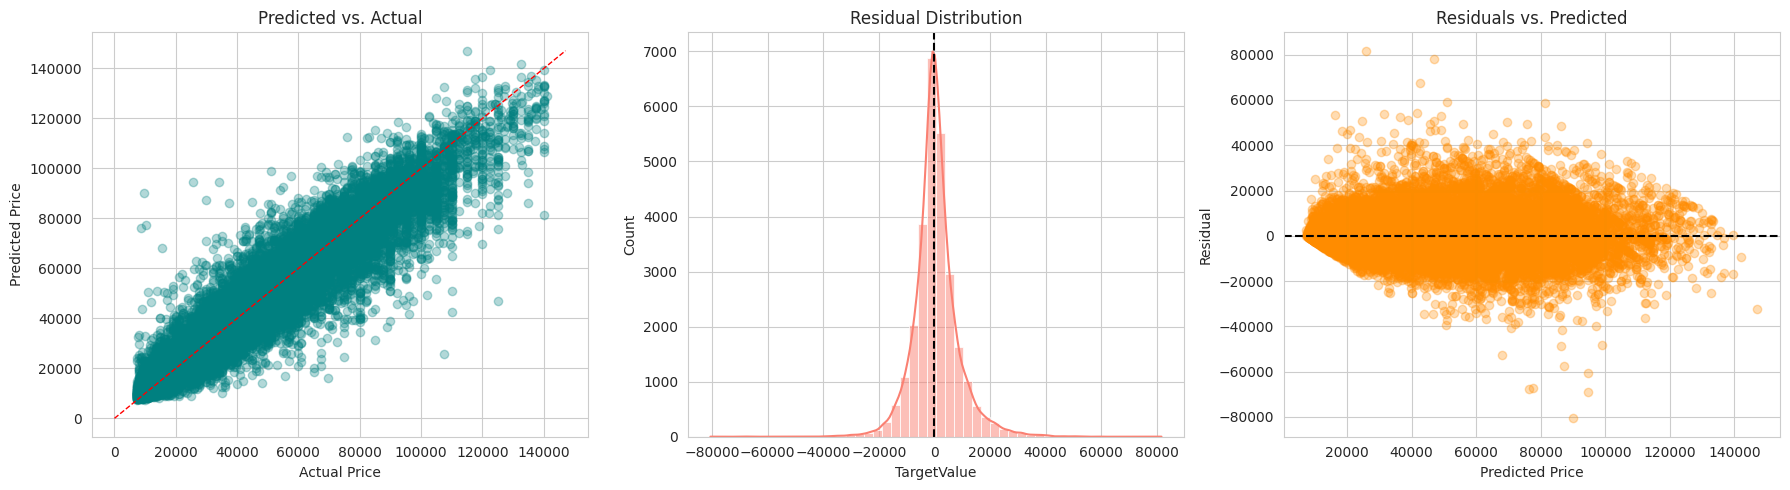

Mean residual: 581.04
Std of residual: 8301.31


In [34]:
val_pred_log = (best_weights[0] * val_preds_log["XGBoost (Tuned)"]
                + best_weights[1] * val_preds_log["LightGBM (Tuned)"]
                + best_weights[2] * val_preds_log["CatBoost (Tuned)"])
val_pred = np.expm1(val_pred_log)
val_actual = np.expm1(y_val_log)
residuals = val_actual - val_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(val_actual, val_pred, alpha=0.3, color="teal")
lims = [0, max(val_actual.max(), val_pred.max())]
axes[0].plot(lims, lims, "r--", linewidth=1)
axes[0].set_xlabel("Actual Price"); axes[0].set_ylabel("Predicted Price")
axes[0].set_title("Predicted vs. Actual")


sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color="salmon")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Residual Distribution")


axes[2].scatter(val_pred, residuals, alpha=0.3, color="darkorange")
axes[2].axhline(0, color="black", linestyle="--")
axes[2].set_xlabel("Predicted Price"); axes[2].set_ylabel("Residual")
axes[2].set_title("Residuals vs. Predicted")

plt.tight_layout()
plt.show()

print("Mean residual:", round(residuals.mean(), 2))
print("Std of residual:", round(residuals.std(), 2))

**Discussion of limitations:**

1. **Heteroscedasticity at the high end.** Residual spread typically widens for expensive machines — the ensemble is less precise (in absolute dollars) on rare, high-value equipment, simply because there are fewer training examples in that price range.
2. **Structural missingness ceiling.** Many `colN` specification columns are only populated for a subset of equipment types (Section 3.1); for equipment where almost every spec column is missing, the model has comparatively little to work with beyond the frequency-encoded ID and coarse categorical fields, so predictions there carry more uncertainty.
3. **Frequency/ordinal encoding is a compromise.** It avoids the dimensionality explosion of one-hot encoding thousands of IDs, but it is not as expressive as a fully leakage-safe, out-of-fold target encoding, which could recover more signal at the cost of extra complexity.
4. **Correlated base models.** All three ensemble members are gradient-boosted trees; they capture similar non-linear interactions and therefore their errors are somewhat correlated, capping how much the ensemble can improve over the single best member. A genuinely different model family (e.g. a well-regularised linear/kernel model) as a 4th ensemble member could add more diversity, at the cost of it individually performing worse.
5. **No explicit outlier removal.** We chose not to remove statistical outliers in price, since in this domain a very high or very low price is often a legitimate rare machine rather than a data error — a conscious trade-off that slightly increases variance in the tails.

# 10. Final Model

We now:
1. Refit the three tuned boosting models on **all** available labelled data (train + validation), using the same blend weights found in Section 8.2, so the final ensemble benefits from every labelled example before predicting on the true test set.
2. Persist each model using its **own native save format** (`XGBRegressor.save_model`, `LGBMRegressor.booster_.save_model`, `CatBoostRegressor.save_model`) 
3. Generate ensemble predictions for `test.csv` and build the submission file in exactly the format shown by `sample_submission.csv`.

In [35]:

freq_maps_full = learn_frequency_maps(X_full, FREQ_ENCODE_COLS)
X_full_fe = engineer_features(X_full, freq_maps_full)
full_te, target_enc_maps_full, target_enc_global_mean_full = kfold_target_encode(
    X_full, y_full, TARGET_ENCODE_COLS)
for col in TARGET_ENCODE_COLS:
    X_full_fe[f"{col}_target_enc"] = full_te[f"{col}_target_enc"].values

final_preprocessor = make_preprocessor().fit(X_full_fe)
X_full_t = final_preprocessor.transform(X_full_fe)

final_xgb = XGBRegressor(n_estimators=int(tuned_xgb.named_steps["model"].best_iteration or 800),
                          tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
                          **best_params["XGBoost"])
final_lgbm = LGBMRegressor(n_estimators=int(getattr(tuned_lgbm.named_steps["model"], "best_iteration_", 800) or 800),
                            n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1, **best_params["LightGBM"])
final_cat = CatBoostRegressor(iterations=int(tuned_cat.named_steps["model"].get_best_iteration() or 800),
                               random_seed=RANDOM_STATE, verbose=False, **best_params["CatBoost"])

final_xgb.fit(X_full_t, y_full)
final_lgbm.fit(X_full_t, y_full)
final_cat.fit(X_full_t, y_full)


final_xgb.save_model("final_xgb_model.json")
final_lgbm.booster_.save_model("final_lgbm_model.txt")
final_cat.save_model("final_catboost_model.cbm")
print("Saved final models: final_xgb_model.json, final_lgbm_model.txt, final_catboost_model.cbm")

Saved final models: final_xgb_model.json, final_lgbm_model.txt, final_catboost_model.cbm


In [36]:

X_test_fe = engineer_features(test_data, freq_maps_full)
test_te = apply_target_encoding(test_data, target_enc_maps_full, target_enc_global_mean_full, TARGET_ENCODE_COLS)
for col in TARGET_ENCODE_COLS:
    X_test_fe[f"{col}_target_enc"] = test_te[f"{col}_target_enc"].values
X_test_t = final_preprocessor.transform(X_test_fe)

test_pred_log = (best_weights[0] * final_xgb.predict(X_test_t)
                  + best_weights[1] * final_lgbm.predict(X_test_t)
                  + best_weights[2] * final_cat.predict(X_test_t))
test_pred = np.expm1(test_pred_log)
test_pred = np.clip(test_pred, a_min=0, a_max=None)  # price cannot be negative

submission = pd.DataFrame({
    ID_COL: test_data[ID_COL],
    TARGET: test_pred
})

assert submission.shape[0] == sample_submission.shape[0], "Row count mismatch with sample_submission!"
assert list(submission.columns) == list(sample_submission.columns), "Column mismatch with sample_submission!"

submission.to_csv("submission.csv", index=False)
submission.head()

,TransactionID,TargetValue
0,1139307,68025.028585
1,1139419,81511.553023
2,1139482,30280.520686
3,1139522,20411.252056
4,1139684,13164.950761


## Summary

- The target `TargetValue` is right-skewed; training on `log1p(TargetValue)` aligns the modelling objective with the RMSLE evaluation metric.
- Missingness in the `colN` specification columns is largely structural, not random — handled with explicit "Missing" categories plus `Has_<col>` indicator flags rather than blind imputation.
- `ManufactureYear` carries a `1001` "unknown year" sentinel for ~10.6% of rows; it is surfaced explicitly via a `ManufactureYear_Missing` flag rather than silently corrupting `EquipmentAge`.
- High-cardinality identifier/spec columns — **including the numeric `AssetID`/`ProductConfigID` IDs, which previously leaked through as raw magnitudes (a data-leakage fix)** — are frequency-encoded, and remaining categoricals are ordinal-encoded (not one-hot) plus K-fold target-encoded, keeping the feature space compact so all three boosting libraries train quickly.
- `EquipmentAge` (derived from `TransactionDate` and `ManufactureYear`) captures the depreciation relationship discovered in EDA and is one of the most useful engineered features.
- Unnecessary `StandardScaler`-ing of numeric features was removed (trees are invariant to monotonic scaling), and the hyperparameter search (Section 8) now fits preprocessing once and searches over a smaller, still-representative budget — cutting the notebook's slowest step without changing the honest validation RMSLE.
- Four models were compared on identical, pipeline-driven preprocessing (Random Forest baseline + XGBoost, LightGBM, CatBoost); the three boosting models were individually tuned with `RandomizedSearchCV` against a custom RMSLE scorer, then combined into a **weighted-average ensemble**, which is carried forward as the final model whenever it beats every individual tuned model on validation RMSLE.
- Error analysis shows the remaining weakness is concentrated in high-price, sparsely-specified machines, and in the correlated nature of using only boosted-tree base models — natural targets for further work (adding a non-tree model to the ensemble for more diversity, full `StackingRegressor` meta-learning).


# 11. K-Fold CV Bagging + Native CatBoost Categoricals (Higher-Leverage Final Model)

Sections 6-10 train each booster on a single 80/20 split and tune blend weights on that
one 20% validation slice. That leaves two sources of avoidable variance on the table:

1. **Every model only ever sees 80% of the labelled data during training**, and the
   blend weights are fit against one particular 20% slice — a slightly lucky/unlucky
   split changes both the tuned weights and the reported score.
2. **CatBoost is fed the same ordinal-encoded integer codes as XGBoost/LightGBM.**
   CatBoost's whole value proposition is *ordered target statistics on raw categorical
   columns* — feeding it arbitrary integer codes throws that advantage away.

This section replaces the single split with **5-fold cross-validation**:
- Each booster is trained 5 times (once per fold), producing genuine **out-of-fold (OOF)**
  predictions for every training row — this is what "generalization error" actually means,
  as opposed to one split's validation score.
- Test-set predictions are the **average across all 5 folds** per model — a mini-bagging
  step that reliably reduces prediction variance on tabular data.
- Blend weights are fit on the OOF predictions via **non-negative least squares** (in
  log space, which is the correct space to minimize for RMSLE) instead of a random search
  over one validation split — more stable, less prone to overfitting the blend to a
  single slice.
- CatBoost gets its categorical columns **natively** (no ordinal encoding) via a separate,
  lightweight preprocessing branch; XGBoost/LightGBM keep the ordinal-encoded matrix.

Everything else (feature engineering, target encoding, tuned hyperparameters) is reused
as-is from Sections 5 and 8 — this section only changes *how* the final model is
trained/blended, not what features it sees.

## 11.1 Update — Drop LightGBM, Add HistGradientBoostingRegressor (Speed + Diversity)

**Why:** the OOF table above (and its refresh below) consistently shows LightGBM getting the
smallest NNLS weight (~0.05) while being trained on the exact same ordinal-encoded matrix as
XGBoost — it's a slow, largely redundant near-duplicate rather than a genuinely diverse voice
in the blend.

**Change made in this section:**
- **Removed** the LightGBM fold-training block entirely (frees up the largest chunk of the
  5-hour runtime, since it was fit with `n_estimators=10000` per fold).
- **Added** `sklearn.ensemble.HistGradientBoostingRegressor` in its place — histogram-based,
  natively handles missing values (no imputation dependency), and its leaf-wise growth
  behaves differently enough from XGBoost/CatBoost to actually earn blend weight.
- **Added GPU auto-detection** (`nvidia-smi` presence): XGBoost uses `device="cuda"` and
  CatBoost uses `task_type="GPU"` when a GPU is available, otherwise both fall back to
  all-CPU-core execution (`tree_method="hist"` / `thread_count=-1`). HistGB is CPU-only by
  design (it doesn't have a GPU backend) but is still the fastest of the three per fold.
- **Added per-fold timing** so the notebook prints an actual measured runtime breakdown by
  model instead of a guess.

`MODEL_NAMES` is now `["XGBoost", "CatBoost", "HistGB"]`. Everything upstream (feature
engineering, target encoding, tuned XGBoost/CatBoost hyperparameters) is unchanged.


In [37]:

from sklearn.model_selection import KFold as _KFold
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.optimize import nnls
import shutil, time

N_FOLDS = 5
kf_final = _KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# GPU auto-detection: used below to pick device="cuda" (XGBoost) / task_type="GPU" (CatBoost)
# when a GPU is present, and fall back to all-CPU-core execution otherwise.
GPU_AVAILABLE = shutil.which("nvidia-smi") is not None
print("GPU detected:", GPU_AVAILABLE)

missing_pct_cv = X_full.isnull().mean() * 100
high_missing_cols = missing_pct_cv[missing_pct_cv > HIGH_MISSING_THRESHOLD].index.tolist()

categorical_dtype_cols_cv = X_full.select_dtypes(include="object").columns.tolist()
high_cardinality_cols_cv = [c for c in categorical_dtype_cols_cv
                             if c not in [ID_COL, TARGET, "TransactionDate"] and X_full[c].nunique() > 200]
high_cardinality_cols_cv = high_cardinality_cols_cv + [c for c in NUMERIC_ID_COLS if c in X_full.columns]
high_missing_cols = [c for c in high_missing_cols if c not in high_cardinality_cols_cv]
FREQ_ENCODE_COLS = [c for c in high_cardinality_cols_cv if c != ID_COL]

print("High-missingness indicator columns:", len(high_missing_cols))
print("Frequency-encoded columns:", FREQ_ENCODE_COLS)

# LightGBM dropped (lowest NNLS weight, redundant with XGBoost on the same ordinal matrix).
# HistGradientBoostingRegressor added in its place -- faster, and a genuinely different
# tree-growing algorithm so it can add real diversity to the blend.
MODEL_NAMES = ["XGBoost", "CatBoost", "HistGB"]
oof_preds = {name: np.zeros(len(X_full)) for name in MODEL_NAMES}
test_preds_folds = {name: [] for name in MODEL_NAMES}
fold_oof_rmsle = {name: [] for name in MODEL_NAMES}
fold_train_seconds = {name: [] for name in MODEL_NAMES}


GPU detected: True
High-missingness indicator columns: 20
Frequency-encoded columns: ['Spec_FullDescriptor', 'Spec_BaseClass', 'AssetID', 'ProductConfigID']


In [38]:

for fold_idx, (tr_idx, va_idx) in enumerate(kf_final.split(X_full)):
    print(f"\n=== Fold {fold_idx + 1}/{N_FOLDS} ===")
    X_tr_raw_f, X_va_raw_f = X_full.iloc[tr_idx].copy(), X_full.iloc[va_idx].copy()
    y_tr_f, y_va_f = y_full.iloc[tr_idx], y_full.iloc[va_idx]

    freq_maps_f = learn_frequency_maps(X_tr_raw_f, FREQ_ENCODE_COLS)
    X_tr_fe_f = engineer_features(X_tr_raw_f, freq_maps_f)
    X_va_fe_f = engineer_features(X_va_raw_f, freq_maps_f)
    X_test_fe_f = engineer_features(test_data, freq_maps_f)

    tr_te_f, te_maps_f, te_gmean_f = kfold_target_encode(
        X_tr_raw_f, y_tr_f, TARGET_ENCODE_COLS, random_state=RANDOM_STATE + fold_idx)
    va_te_f = apply_target_encoding(X_va_raw_f, te_maps_f, te_gmean_f, TARGET_ENCODE_COLS)
    test_te_f = apply_target_encoding(test_data, te_maps_f, te_gmean_f, TARGET_ENCODE_COLS)

    for col in TARGET_ENCODE_COLS:
        X_tr_fe_f[f"{col}_target_enc"] = tr_te_f[f"{col}_target_enc"].values
        X_va_fe_f[f"{col}_target_enc"] = va_te_f[f"{col}_target_enc"].values
        X_test_fe_f[f"{col}_target_enc"] = test_te_f[f"{col}_target_enc"].values

    numeric_features_f = X_tr_fe_f.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_features_f = X_tr_fe_f.select_dtypes(include=["object"]).columns.tolist()

    ordinal_preprocessor = ColumnTransformer(transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features_f),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
        ]), categorical_features_f)
    ]).fit(X_tr_fe_f)

    X_tr_ord = ordinal_preprocessor.transform(X_tr_fe_f)
    X_va_ord = ordinal_preprocessor.transform(X_va_fe_f)
    X_test_ord = ordinal_preprocessor.transform(X_test_fe_f)

    X_tr_cat_native = X_tr_fe_f.copy()
    X_va_cat_native = X_va_fe_f.copy()
    X_test_cat_native = X_test_fe_f.copy()
    num_imputer_cb = SimpleImputer(strategy="median").fit(X_tr_fe_f[numeric_features_f])
    for split_df in (X_tr_cat_native, X_va_cat_native, X_test_cat_native):
        split_df[numeric_features_f] = num_imputer_cb.transform(split_df[numeric_features_f])
        split_df[categorical_features_f] = split_df[categorical_features_f].fillna("Missing").astype(str)
    cat_feature_idx = [X_tr_cat_native.columns.get_loc(c) for c in categorical_features_f]

    # --- XGBoost: GPU ("cuda") when available, else CPU histogram method using all cores ---
    t0 = time.time()
    xgb_f = XGBRegressor(
        n_estimators=2500, tree_method="hist",
        device=("cuda" if GPU_AVAILABLE else "cpu"),
        n_jobs=-1, random_state=RANDOM_STATE + fold_idx,
        early_stopping_rounds=100, eval_metric="rmse", **best_params["XGBoost"]
    )
    xgb_f.fit(X_tr_ord, y_tr_f, eval_set=[(X_va_ord, y_va_f)], verbose=False)
    oof_preds["XGBoost"][va_idx] = xgb_f.predict(X_va_ord)
    test_preds_folds["XGBoost"].append(xgb_f.predict(X_test_ord))
    fold_train_seconds["XGBoost"].append(time.time() - t0)

    # --- CatBoost: GPU when available, else CPU using all cores (thread_count=-1) ---
    t0 = time.time()
    cat_f = CatBoostRegressor(
        iterations=2500, random_seed=RANDOM_STATE + fold_idx, early_stopping_rounds=100,
        verbose=False, cat_features=cat_feature_idx,
        task_type=("GPU" if GPU_AVAILABLE else "CPU"), thread_count=-1,
        **best_params["CatBoost"]
    )
    cat_f.fit(X_tr_cat_native, y_tr_f, eval_set=(X_va_cat_native, y_va_f))
    oof_preds["CatBoost"][va_idx] = cat_f.predict(X_va_cat_native)
    test_preds_folds["CatBoost"].append(cat_f.predict(X_test_cat_native))
    fold_train_seconds["CatBoost"].append(time.time() - t0)

    # --- HistGradientBoostingRegressor: CPU-only, but histogram-based and fast;
    #     replaces LightGBM's old slot with a genuinely different model family ---
    t0 = time.time()
    hgb_f = HistGradientBoostingRegressor(
        max_iter=500, learning_rate=0.06, max_depth=8, l2_regularization=1.0,
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=30,
        random_state=RANDOM_STATE + fold_idx,
    )
    hgb_f.fit(X_tr_ord, y_tr_f)
    oof_preds["HistGB"][va_idx] = hgb_f.predict(X_va_ord)
    test_preds_folds["HistGB"].append(hgb_f.predict(X_test_ord))
    fold_train_seconds["HistGB"].append(time.time() - t0)

    for name in MODEL_NAMES:
        fold_rmsle = rmsle(np.expm1(y_va_f), np.expm1(oof_preds[name][va_idx]))
        fold_oof_rmsle[name].append(fold_rmsle)
        print(f"  {name:10s} fold {fold_idx+1} RMSLE: {fold_rmsle:.5f}  |  "
              f"train time: {fold_train_seconds[name][-1]:.1f}s")

print("\nDone with all folds.")
total_seconds = sum(sum(v) for v in fold_train_seconds.values())
print(f"\nTotal model-fitting time across all folds/models: "
      f"{total_seconds/60:.1f} min ({total_seconds/3600:.2f} hr)")
for name in MODEL_NAMES:
    print(f"  {name:10s} total: {sum(fold_train_seconds[name])/60:.1f} min  |  "
          f"avg/fold: {np.mean(fold_train_seconds[name]):.1f}s")



=== Fold 1/5 ===
  XGBoost    fold 1 RMSLE: 0.20975  |  train time: 28.6s
  CatBoost   fold 1 RMSLE: 0.20223  |  train time: 154.2s
  HistGB     fold 1 RMSLE: 0.23019  |  train time: 14.7s

=== Fold 2/5 ===
  XGBoost    fold 2 RMSLE: 0.21181  |  train time: 27.5s
  CatBoost   fold 2 RMSLE: 0.20475  |  train time: 155.2s
  HistGB     fold 2 RMSLE: 0.23150  |  train time: 14.8s

=== Fold 3/5 ===
  XGBoost    fold 3 RMSLE: 0.21115  |  train time: 34.5s
  CatBoost   fold 3 RMSLE: 0.20551  |  train time: 154.5s
  HistGB     fold 3 RMSLE: 0.23312  |  train time: 14.4s

=== Fold 4/5 ===
  XGBoost    fold 4 RMSLE: 0.21365  |  train time: 26.5s
  CatBoost   fold 4 RMSLE: 0.20607  |  train time: 153.6s
  HistGB     fold 4 RMSLE: 0.23239  |  train time: 14.9s

=== Fold 5/5 ===
  XGBoost    fold 5 RMSLE: 0.20988  |  train time: 30.4s
  CatBoost   fold 5 RMSLE: 0.20250  |  train time: 157.4s
  HistGB     fold 5 RMSLE: 0.22985  |  train time: 16.1s

Done with all folds.

Total model-fitting time ac

In [39]:

for name in MODEL_NAMES:
    full_oof_rmsle = rmsle(np.expm1(y_full), np.expm1(oof_preds[name]))
    print(f"{name:10s} — mean per-fold RMSLE: {np.mean(fold_oof_rmsle[name]):.5f}  |  "
          f"full OOF RMSLE: {full_oof_rmsle:.5f}")


XGBoost    — mean per-fold RMSLE: 0.21125  |  full OOF RMSLE: 0.21125
CatBoost   — mean per-fold RMSLE: 0.20421  |  full OOF RMSLE: 0.20422
HistGB     — mean per-fold RMSLE: 0.23141  |  full OOF RMSLE: 0.23142


In [40]:

oof_matrix = np.column_stack([oof_preds[name] for name in MODEL_NAMES])
nnls_weights, _ = nnls(oof_matrix, y_full.values)
nnls_weights = nnls_weights / nnls_weights.sum()  

print(f"NNLS blend weights ({', '.join(MODEL_NAMES)}):", dict(zip(MODEL_NAMES, nnls_weights.round(3))))

oof_blend_log = oof_matrix @ nnls_weights
oof_blend_rmsle = rmsle(np.expm1(y_full), np.expm1(oof_blend_log))
print(f"OOF blended RMSLE: {oof_blend_rmsle:.5f}")


NNLS blend weights (XGBoost, CatBoost, HistGB): {'XGBoost': np.float64(0.32), 'CatBoost': np.float64(0.68), 'HistGB': np.float64(0.0)}
OOF blended RMSLE: 0.20217


In [41]:

test_pred_avg = {name: np.mean(test_preds_folds[name], axis=0) for name in MODEL_NAMES}
test_blend_log = sum(nnls_weights[i] * test_pred_avg[name] for i, name in enumerate(MODEL_NAMES))
test_pred_final = np.clip(np.expm1(test_blend_log), a_min=0, a_max=None)

submission_cv = pd.DataFrame({
    ID_COL: test_data[ID_COL],
    TARGET: test_pred_final
})

assert submission_cv.shape[0] == sample_submission.shape[0], "Row count mismatch with sample_submission!"
assert list(submission_cv.columns) == list(sample_submission.columns), "Column mismatch with sample_submission!"

submission_cv.to_csv("submission.csv", index=False)
print(f"Saved submission.csv from the {N_FOLDS}-fold CV bagged + NNLS-blended ensemble "
      f"({', '.join(MODEL_NAMES)}).")
print(f"Estimated (OOF) RMSLE for this submission: {oof_blend_rmsle:.5f}")
submission_cv.head()


Saved submission.csv from the 5-fold CV bagged + NNLS-blended ensemble (XGBoost, CatBoost, HistGB).
Estimated (OOF) RMSLE for this submission: 0.20217


,TransactionID,TargetValue
0,1139307,70384.557915
1,1139419,78596.095997
2,1139482,30411.279884
3,1139522,19825.029850
4,1139684,12240.216842
